In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [2]:
df= pd.read_csv('customer_churn.csv')

In [3]:
df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,SeniorCitizen,Churn
0,22,3,29.85,89.55,Month-to-month,DSL,Electronic check,0,0
1,35,24,56.95,1366.80,One year,Fiber optic,Mailed check,0,0
2,58,2,70.70,141.40,Month-to-month,Fiber optic,Electronic check,1,1
3,41,36,42.30,1522.80,Two year,DSL,Bank transfer,0,0
4,29,8,89.10,712.80,Month-to-month,Fiber optic,Electronic check,0,1


In [4]:
df.isnull().sum()

Age                0
Tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
InternetService    0
PaymentMethod      0
SeniorCitizen      0
Churn              0
dtype: int64

In [5]:
df.shape

(30, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              30 non-null     int64  
 1   Tenure           30 non-null     int64  
 2   MonthlyCharges   30 non-null     float64
 3   TotalCharges     30 non-null     float64
 4   Contract         30 non-null     object 
 5   InternetService  30 non-null     object 
 6   PaymentMethod    30 non-null     object 
 7   SeniorCitizen    30 non-null     int64  
 8   Churn            30 non-null     int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 2.2+ KB


In [7]:
df.describe()

,Age,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,43.233333,25.933333,63.106667,1360.868333,0.333333,0.400000
std,14.919747,23.161998,18.934600,1009.001461,0.479463,0.498273
min,22.000000,2.000000,29.850000,89.550000,0.000000,0.000000
25%,30.250000,6.250000,46.675000,505.687500,0.000000,0.000000
50%,41.500000,16.500000,61.825000,1000.550000,0.000000,0.000000
75%,56.500000,43.750000,77.637500,2230.437500,1.000000,1.000000
max,70.000000,72.000000,95.300000,3107.000000,1.000000,1.000000


In [8]:
df['Churn'].value_counts()

Churn
0    18
1    12
Name: count, dtype: int64

In [9]:
X=df.drop('Churn', axis=1)
y=df['Churn']

In [10]:
X

,Age,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,SeniorCitizen
0,22,3,29.85,89.55,Month-to-month,DSL,Electronic check,0
1,35,24,56.95,1366.80,One year,Fiber optic,Mailed check,0
2,58,2,70.70,141.40,Month-to-month,Fiber optic,Electronic check,1
3,41,36,42.30,1522.80,Two year,DSL,Bank transfer,0
4,29,8,89.10,712.80,Month-to-month,Fiber optic,Electronic check,0
5,67,60,45.25,2715.00,Two year,DSL,Credit card,1
6,31,12,75.50,906.00,One year,Fiber optic,Bank transfer,0
7,46,5,95.30,476.50,Month-to-month,Fiber optic,Electronic check,0
8,25,18,35.20,633.60,One year,DSL,Mailed check,0
9,52,48,62.40,2995.20,Two year,DSL,Credit card,1


In [11]:
y

0     0
1     0
2     1
3     0
4     1
5     0
6     0
7     1
8     0
9     0
10    1
11    0
12    1
13    0
14    1
15    0
16    1
17    0
18    0
19    1
20    0
21    0
22    1
23    0
24    1
25    0
26    1
27    0
28    1
29    0
Name: Churn, dtype: int64

In [12]:
X=pd.get_dummies(X,drop_first=True)

In [13]:
# Split dataset Train and test
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y, test_size=0.20, random_state=42, stratify=y)


In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [16]:
y_prob=model.predict_proba(X_test)[:,1]

In [19]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix,recall_score, f1_score,precision_score

print("accuracy_score",accuracy_score(y_pred,y_test))
print("\nclassification_report",classification_report(y_pred,y_test))
print("\nconfusion_matrix",confusion_matrix(y_pred,y_test))
print("recall_score", recall_score(y_pred,y_test))
print("f1_score",f1_score(y_pred,y_test))
print("precision_score",precision_score(y_pred,y_test))

accuracy_score 0.8333333333333334

classification_report               precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.50      1.00      0.67         1

    accuracy                           0.83         6
   macro avg       0.75      0.90      0.78         6
weighted avg       0.92      0.83      0.85         6


confusion_matrix [[4 1]
 [0 1]]
recall_score 1.0
f1_score 0.6666666666666666
precision_score 0.5


In [20]:
y.value_counts()

Churn
0    18
1    12
Name: count, dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [24]:
from sklearn.model_selection import GridSearchCV

params={
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

grid=GridSearchCV(LogisticRegression(class_weight="balanced", max_iter=1000), param_grid=params,cv=5, scoring="f1",n_jobs=-1)
grid.fit(X_train,y_train)

c:\Users\Abhi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1')

In [25]:
grid.best_params_

{'C': 10, 'penalty': 'l1', 'solver': 'saga'}

In [26]:
grid.best_score_

np.float64(0.9333333333333332)

In [27]:
best_model=grid.best_estimator_

In [28]:
from sklearn.metrics import roc_curve,roc_auc_score

y_prob=best_model.predict_proba(X_test)[:,1]
auc=roc_auc_score(y_test,y_prob)
print(auc)

0.875


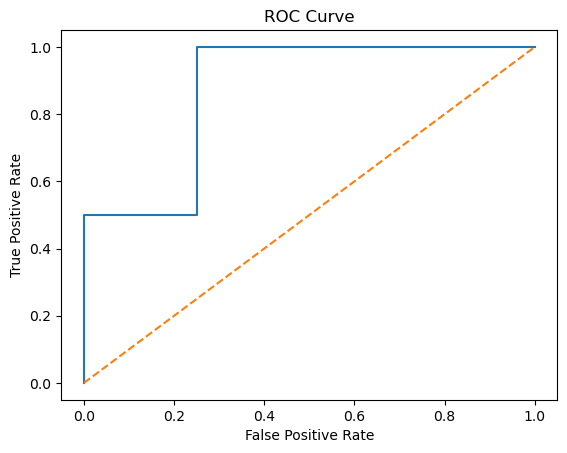

In [29]:
# plot the roc curve
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")

plt.show()